# Redes Neuronales (MLP) e Intervalos de Predicción con JAX

> *Una red neuronal no solo puede predecir un valor esperado, sino también
> cuantificar la incertidumbre asociada a esa predicción.*

En este laboratorio implementamos un **perceptrón multicapa (MLP)**
**desde cero usando únicamente JAX** (sin `flax` ni `optax`). El objetivo es
estimar **intervalos de predicción** sobre datos con ruido heterocedástico
(la varianza del ruido crece con la entrada), siguiendo el ejemplo de
[*Prediction Intervals for Gradient Boosting Regression*](https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_quantile.html)
de scikit-learn.

Comparamos **tres enfoques** para el mismo problema:

1. **MLP + verosimilitud Gaussiana (NLL)**: la red predice simultáneamente la
   media $\mu(x)$ y la varianza $\sigma^2(x)$. *(ambos parámetros desconocidos)*
2. **MLP + pérdida pinball**: regresión cuantílica; la red predice directamente
   los cuantiles $5\%$, $50\%$ y $95\%$.
3. **Histogram Gradient Boosting** (`sklearn`): el método de referencia del
   ejemplo original, con pérdida cuantílica.

Todo lo relacionado con la red (inicialización, paso *forward*, optimizador
**SGD con momentum** y descenso de gradiente) se implementa manualmente con
`jax.grad` y `jax.jit`.

## 1. Importar librerías necesarias

Importamos `jax` para el cálculo automático de gradientes y la compilación JIT,
`numpy`/`matplotlib` para datos y visualización, y de `scikit-learn` únicamente
el modelo de *boosting* de referencia (enfoque 3).

In [68]:
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import grad, jit, value_and_grad
from jax.tree_util import tree_map

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor

RANDOM_STATE = 42   # semilla única para todo el laboratorio (reproducibilidad)

print("JAX", jax.__version__, "| dispositivo:", jax.devices()[0])

JAX 0.10.1 | dispositivo: cuda:0


## 2. Generar datos sintéticos

Reproducimos el conjunto de datos del ejemplo de scikit-learn. La función
generadora es $f(x) = x\,\sin(x)$ y se le añade un **ruido log-normal
heterocedástico**: su dispersión $\sigma$ crece con $x$. Esto hace que el
intervalo de predicción deba *ensancharse* a medida que aumenta $x$, y además
el ruido es **asimétrico** (sesgado), lo que distingue a los tres enfoques.

In [2]:
def f(x):
    '''Función verdadera (media condicional) sin ruido.'''
    return x * np.sin(x)

rng = np.random.RandomState(RANDOM_STATE)

n_samples = 1000
X = rng.uniform(0.0, 10.0, size=n_samples).reshape(-1, 1)
expected_y = f(X).ravel()

# Ruido log-normal cuya dispersión aumenta con x (heterocedástico y asimétrico)
sigma = 0.5 + X.ravel() / 10.0
noise = rng.lognormal(mean=0.0, sigma=sigma) - np.exp(sigma**2 / 2.0)
y = expected_y + noise

print("X:", X.shape, "| y:", y.shape)

X: (1000, 1) | y: (1000,)


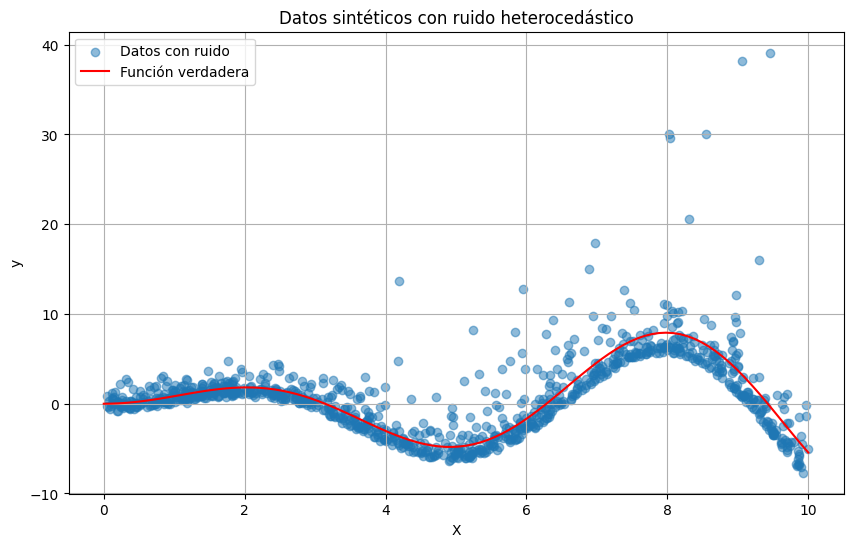

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Datos con ruido')
x_line = np.linspace(0, 10, 100).reshape(-1, 1)
plt.plot(x_line, f(x_line), color='red', label='Función verdadera')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Datos sintéticos con ruido heterocedástico')
plt.legend()
plt.grid()
plt.show()  

### 2.1 Dividir en entrenamiento y prueba

Usamos una partición **70% / 30%** con `random_state=RANDOM_STATE` para reproducibilidad.
(Al ser un problema de regresión no aplica `stratify`.)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")

Entrenamiento: 700 muestras
Prueba:        300 muestras


### 2.2 Estandarización

Las redes neuronales entrenan mucho mejor con entradas y salidas centradas y
escaladas. Estandarizamos $X$ e $y$ usando **solo las estadísticas de
entrenamiento** (para no filtrar información del conjunto de prueba). Más
adelante des-estandarizamos las predicciones para volver a la escala original.

Si $y_{\text{std}} = (y - \mu_y)/s_y$, entonces para una predicción en la escala
estandarizada:
$$\mu = \mu_{\text{std}}\, s_y + \mu_y, \qquad \sigma = \sigma_{\text{std}}\, s_y.$$

In [6]:
x_mean, x_sd = X_train.mean(), X_train.std()
y_mean, y_sd = y_train.mean(), y_train.std()

def standardize_X(a):
    return (a - x_mean) / x_sd

# Tensores JAX estandarizados para el entrenamiento
Xtr = jnp.asarray(standardize_X(X_train))
ytr = jnp.asarray((y_train - y_mean) / y_sd)
Xte = jnp.asarray(standardize_X(X_test))

# Malla ordenada para graficar las curvas suaves
xx = np.linspace(0.0, 10.0, 400).reshape(-1, 1)
Xgrid = jnp.asarray(standardize_X(xx))

## 3. Implementación del MLP en JAX

Un MLP es una composición de capas afines seguidas de una no linealidad:
$$h^{(l)} = \tanh\!\big(h^{(l-1)} W^{(l)} + b^{(l)}\big),$$
y una capa de salida lineal. Implementamos tres piezas básicas:

- **`init_mlp`**: inicializa los parámetros (lista de tuplas `(W, b)`) con
  inicialización de *He* a partir de una semilla `PRNGKey`.
- **`mlp_forward`**: el paso hacia adelante con activación `tanh`.
- **`sgd_step`**: una iteración del **descenso de gradiente estocástico (SGD)
  con momentum**, implementado a mano con `tree_map` sobre los parámetros.

In [7]:
def init_mlp(key, layer_sizes):
    '''Inicializa los pesos (He) y sesgos (0) de un MLP.'''
    params = []
    keys = jax.random.split(key, len(layer_sizes) - 1)
    for k, din, dout in zip(keys, layer_sizes[:-1], layer_sizes[1:]):
        wk, _ = jax.random.split(k)
        W = jax.random.normal(wk, (din, dout)) * jnp.sqrt(2.0 / din)
        b = jnp.zeros((dout,))
        params.append((W, b))
    return params

def mlp_forward(params, x):
    '''Paso forward: capas ocultas con tanh y salida lineal.'''
    a = x
    for W, b in params[:-1]:
        a = jnp.tanh(a @ W + b)
    W, b = params[-1]
    return a @ W + b

In [69]:
params_key,random_key = jax.random.split(jax.random.PRNGKey(RANDOM_STATE))
params = init_mlp(params_key, [1, 64, 64, 1])
print("Número de parámetros:", sum(p.size for layer in params for p in layer))

Número de parámetros: 4353


In [70]:
64*(1 + 1) + 64*(64 + 1) + 1*(64 + 1)

4353

In [71]:
tree_map(lambda p: p.shape, params)

[((1, 64), (64,)), ((64, 64), (64,)), ((64, 1), (1,))]

**SGD Momemtum**

\begin{split}\begin{aligned}
\mathbf{v}_t &\leftarrow \beta \mathbf{v}_{t-1} + \mathbf{g}_{t, t-1}, \\
\mathbf{x}_t &\leftarrow \mathbf{x}_{t-1} - \eta_t \mathbf{v}_t.
\end{aligned}\end{split}

In [38]:
def init_sgd(params):
    '''Vector de velocidad (momentum) inicializado en cero.'''
    return tree_map(jnp.zeros_like, params)

def sgd_step(params, grads, velocity, lr=1e-2, momentum=0.9):
    '''Una actualización de SGD con momentum sobre el árbol de parámetros.'''
    velocity = tree_map(lambda v_, g: momentum * v_ + g, velocity, grads)
    params = tree_map(lambda p, v_: p - lr * v_, params, velocity)
    return params, velocity

Una función de entrenamiento genérica: dada una **función de pérdida**,
ejecuta `n_epochs` de descenso de gradiente *full-batch* con **SGD (momentum)**. Usamos
`value_and_grad` para obtener pérdida y gradiente en una sola pasada, y `jit`
para compilar el paso de entrenamiento.

In [49]:
def train(loss_fn, params, X, y, n_epochs=4000, lr=1e-2, log_every=1000):
    '''Entrena `params` minimizando `loss_fn(params, X, y)` con SGD (momentum).'''
    velocity = init_sgd(params)

    @jit
    def step(params, velocity):
        loss, grads = value_and_grad(loss_fn)(params, X, y)
        params, velocity = sgd_step(params, grads, velocity, lr=lr)
        return params, velocity, loss

    history = []
    for epoch in range(1, n_epochs + 1):
        params, velocity, loss = step(params, velocity)
        history.append(float(loss))
        if epoch % log_every == 0 or epoch == 1:
            print(f"  época {epoch:5d}  |  pérdida = {loss:.4f}")
    return params, history

## 4. Enfoque 1 — MLP con verosimilitud Gaussiana (media y varianza)

Suponemos que, condicionado a $x$, la respuesta es Gaussiana:
$$y \mid x \;\sim\; \mathcal{N}\big(\mu(x),\, \sigma^2(x)\big).$$

La red tiene **dos salidas**: $\mu(x)$ y $\log\sigma^2(x)$ (predecimos el
*logaritmo* de la varianza para garantizar $\sigma^2 > 0$ y mayor estabilidad).
Minimizamos la **log-verosimilitud negativa** (NLL):
$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N}
\frac{1}{2}\log\sigma^2(x_i) + \frac{(y_i - \mu(x_i))^2}{2\,\sigma^2(x_i)}.$$

El primer término penaliza varianzas grandes; el segundo es un error cuadrático
*ponderado* por la incertidumbre. Así la red aprende **dónde** confiar más.

In [72]:
def gaussian_nll(params, x, y):
    out = mlp_forward(params, x)          # (N, 2)
    mu = out[:, 0]
    log_var = jnp.clip(out[:, 1], -7.0, 7.0)   # estabilidad numérica
    return jnp.mean(0.5 * log_var + 0.5 * (y - mu) ** 2 * jnp.exp(-log_var))

params_gaussian_key,random_key = jax.random.split(random_key)
params_nll = init_mlp(params_gaussian_key, [1, 64, 64, 2])

print("Entrenando MLP con NLL Gaussiana...")
params_nll, hist_nll = train(gaussian_nll, params_nll, Xtr, ytr,
                             n_epochs=20000, lr=1e-2)

Entrenando MLP con NLL Gaussiana...
  época     1  |  pérdida = 1.2605
  época  1000  |  pérdida = -0.2868
  época  2000  |  pérdida = -0.3170
  época  3000  |  pérdida = -0.3395
  época  4000  |  pérdida = -0.3496
  época  5000  |  pérdida = -0.3556
  época  6000  |  pérdida = -0.3609
  época  7000  |  pérdida = -0.3635
  época  8000  |  pérdida = -0.3662
  época  9000  |  pérdida = -0.3685
  época 10000  |  pérdida = -0.3719
  época 11000  |  pérdida = -0.3753
  época 12000  |  pérdida = -0.3796
  época 13000  |  pérdida = -0.3828
  época 14000  |  pérdida = -0.3861
  época 15000  |  pérdida = -0.3907
  época 16000  |  pérdida = -0.3936
  época 17000  |  pérdida = -0.3965
  época 18000  |  pérdida = -0.4015
  época 19000  |  pérdida = -0.3998
  época 20000  |  pérdida = -0.4082


In [ ]:
from jax.scipy.special import gammaln

def tstudent_loss(params, x, y):
    out = mlp_forward(params, x)               # (N, 3): mu, log(sigma^2), nu_raw
    mu = out[:, 0]
    log_var = jnp.clip(out[:, 1], -7.0, 7.0)   # estabilidad numérica
    sigma = jnp.exp(0.5 * log_var)
    nu = 2.0 + jax.nn.softplus(out[:, 2])      # grados de libertad nu > 2 (varianza finita)
    z = (y - mu) / sigma
    # NLL de la t de Student (location-scale): colas más pesadas -> robusta a outliers
    nll = (gammaln(nu / 2.0) - gammaln((nu + 1.0) / 2.0)
           + 0.5 * jnp.log(nu * jnp.pi) + 0.5 * log_var
           + 0.5 * (nu + 1.0) * jnp.log1p(z ** 2 / nu))
    return jnp.mean(nll)

params_tstudent_key,random_key = jax.random.split(random_key)
params_tstudent = init_mlp(params_tstudent_key, [1, 64, 64, 3]) 
print("Entrenando MLP con pérdida t-student...")
params_tstudent, hist_tstudent = train(tstudent_loss, params_tstudent, Xtr, ytr,
                                     n_epochs=20000, lr=1e-2)   


### 4.1 Predicción del intervalo

Con $\mu(x)$ y $\sigma(x)$ construimos un intervalo de predicción del $90\%$
usando los cuantiles de la Gaussiana estándar
($z_{0.95} \approx 1.645$): $\;[\mu - 1.645\,\sigma,\; \mu + 1.645\,\sigma]$.
Recordar des-estandarizar a la escala original de $y$.

In [ ]:
Z90 = 1.645  # cuantil 0.95 de la normal estándar -> intervalo central del 90%

def gaussian_predict(params, Xstd):
    out = np.asarray(mlp_forward(params, Xstd))
    mu_std = out[:, 0]
    sigma_std = np.exp(0.5 * np.clip(out[:, 1], -7.0, 7.0))
    mu = mu_std * y_sd + y_mean
    sigma = sigma_std * y_sd
    return mu, sigma

mu_g, sigma_g = gaussian_predict(params_nll, Xgrid)
lo_g, hi_g = mu_g - Z90 * sigma_g, mu_g + Z90 * sigma_g

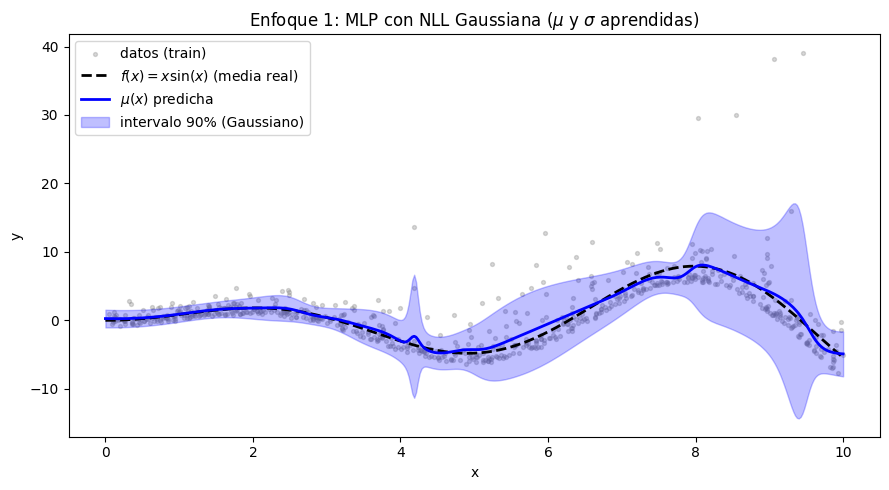

In [74]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_train, y_train, s=8, alpha=0.3, color="gray", label="datos (train)")
ax.plot(xx, f(xx), "k--", lw=2, label=r"$f(x)=x\sin(x)$ (media real)")
ax.plot(xx, mu_g, "b-", lw=2, label=r"$\mu(x)$ predicha")
ax.fill_between(xx.ravel(), lo_g, hi_g, alpha=0.25, color="blue",
                label="intervalo 90% (Gaussiano)")
ax.set_title("Enfoque 1: MLP con NLL Gaussiana ($\\mu$ y $\\sigma$ aprendidas)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

### 4.2 Predicción del intervalo (t-student)

La red t-student predice $\mu(x)$, $\sigma(x)$ y los **grados de libertad**
$\nu(x)$. A diferencia de la Gaussiana, el intervalo del $90\%$ usa el cuantil
$0.95$ de la **distribución t** (que depende de $\nu$, *por punto*):
$$[\,\mu - t_{0.95,\nu}\,\sigma,\;\; \mu + t_{0.95,\nu}\,\sigma\,].$$
Como $t_{0.95,\nu} > z_{0.95}$ para $\nu$ pequeño, las **colas más pesadas**
ensanchan el intervalo donde el ruido tiene *outliers*.

In [ ]:
from scipy.stats import t as student_t

def tstudent_predict(params, Xstd):
    '''Devuelve (mu, sigma, nu) en la escala original de y.'''
    out = np.asarray(mlp_forward(params, Xstd))            # (N, 3)
    mu_std = out[:, 0]
    sigma_std = np.exp(0.5 * np.clip(out[:, 1], -7.0, 7.0))
    nu = 2.0 + np.logaddexp(0.0, out[:, 2])               # softplus -> nu > 2
    mu = mu_std * y_sd + y_mean
    sigma = sigma_std * y_sd
    return mu, sigma, nu

mu_ts, sigma_ts, nu_ts = tstudent_predict(params_tstudent, Xgrid)
t90 = student_t.ppf(0.95, df=nu_ts)   # cuantil 0.95 de la t (depende de nu, por punto)
lo_ts, hi_ts = mu_ts - t90 * sigma_ts, mu_ts + t90 * sigma_ts

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_train, y_train, s=8, alpha=0.3, color="gray", label="datos (train)")
ax.plot(xx, f(xx), "k--", lw=2, label=r"$f(x)=x\sin(x)$ (media real)")
ax.plot(xx, mu_ts, color="purple", lw=2, label=r"$\mu(x)$ predicha")
ax.fill_between(xx.ravel(), lo_ts, hi_ts, alpha=0.25, color="purple",
                label="intervalo 90% (t-student)")
ax.set_title("Enfoque 1b: MLP con NLL t-student ($\\mu$, $\\sigma$ y $\\nu$ aprendidas)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

## 5. Enfoque 2 — MLP con pérdida pinball (regresión cuantílica)

En lugar de suponer una distribución, estimamos **directamente los cuantiles**
condicionales. Para el cuantil $q \in (0,1)$, la **pérdida pinball** (o
*quantile loss*) es:
$$\ell_q(y, \hat{y}) = \max\big(q\,(y-\hat{y}),\; (q-1)(y-\hat{y})\big).$$

Minimizar $\mathbb{E}[\ell_q]$ produce el cuantil $q$ de $y\mid x$. Penaliza de
forma **asimétrica** las subestimaciones y sobreestimaciones, por lo que captura
el sesgo del ruido sin asumir simetría (a diferencia del enfoque Gaussiano).

Usamos **una sola red con 3 salidas** (cuantiles $0.05$, $0.5$, $0.95$) y
sumamos las tres pérdidas pinball. Es más eficiente que entrenar tres redes.

In [75]:
QUANTILES = jnp.array([0.05, 0.5, 0.95])

def pinball_loss(params, x, y):
    pred = mlp_forward(params, x)            # (N, 3): un cuantil por columna
    err = y[:, None] - pred                  # (N, 3)
    loss = jnp.maximum(QUANTILES * err, (QUANTILES - 1.0) * err)
    return jnp.mean(loss)

params_pinball_key,random_key = jax.random.split(random_key)
params_pin = init_mlp(params_pinball_key, [1, 64, 64, 3])

print("Entrenando MLP con pérdida pinball...")
params_pin, hist_pin = train(pinball_loss, params_pin, Xtr, ytr,
                             n_epochs=20000, lr=1e-2)

Entrenando MLP con pérdida pinball...
  época     1  |  pérdida = 0.5083
  época  1000  |  pérdida = 0.1198
  época  2000  |  pérdida = 0.1019
  época  3000  |  pérdida = 0.0934
  época  4000  |  pérdida = 0.0905
  época  5000  |  pérdida = 0.0887
  época  6000  |  pérdida = 0.0878
  época  7000  |  pérdida = 0.0876
  época  8000  |  pérdida = 0.0875
  época  9000  |  pérdida = 0.0874
  época 10000  |  pérdida = 0.0874
  época 11000  |  pérdida = 0.0873
  época 12000  |  pérdida = 0.0873
  época 13000  |  pérdida = 0.0872
  época 14000  |  pérdida = 0.0872
  época 15000  |  pérdida = 0.0872
  época 16000  |  pérdida = 0.0871
  época 17000  |  pérdida = 0.0871
  época 18000  |  pérdida = 0.0871
  época 19000  |  pérdida = 0.0870
  época 20000  |  pérdida = 0.0870


### 5.1 Predicción de los cuantiles

Des-estandarizamos cada cuantil. El intervalo del $90\%$ queda definido
directamente por los cuantiles $5\%$ y $95\%$; el cuantil $50\%$ es la mediana
predicha.

In [76]:
def quantile_predict(params, Xstd):
    pred = np.asarray(mlp_forward(params, Xstd))   # (N, 3) estandarizado
    return pred * y_sd + y_mean

q_grid = quantile_predict(params_pin, Xgrid)
lo_p, med_p, hi_p = q_grid[:, 0], q_grid[:, 1], q_grid[:, 2]

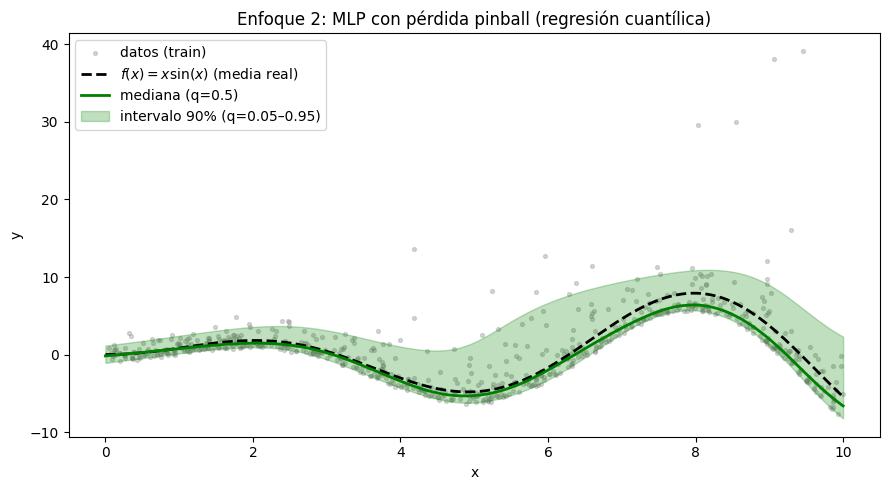

In [77]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_train, y_train, s=8, alpha=0.3, color="gray", label="datos (train)")
ax.plot(xx, f(xx), "k--", lw=2, label=r"$f(x)=x\sin(x)$ (media real)")
ax.plot(xx, med_p, "g-", lw=2, label="mediana (q=0.5)")
ax.fill_between(xx.ravel(), lo_p, hi_p, alpha=0.25, color="green",
                label="intervalo 90% (q=0.05–0.95)")
ax.set_title("Enfoque 2: MLP con pérdida pinball (regresión cuantílica)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

## 6. Enfoque 3 — Histogram Gradient Boosting (scikit-learn)

El método de referencia del ejemplo original. `HistGradientBoostingRegressor`
admite `loss="quantile"`, por lo que ajustamos **un modelo por cuantil**
($0.05$, $0.5$, $0.95$). Estos modelos operan sobre los datos en su **escala
original** (los árboles no requieren estandarización).

In [78]:
common = dict(max_iter=200, max_depth=2, learning_rate=0.1,
              min_samples_leaf=9, random_state=RANDOM_STATE)

hgb = {}
for q in [0.05, 0.5, 0.95]:
    model = HistGradientBoostingRegressor(loss="quantile", quantile=q, **common)
    model.fit(X_train, y_train.ravel())
    hgb[q] = model

lo_h = hgb[0.05].predict(xx)
med_h = hgb[0.50].predict(xx)
hi_h = hgb[0.95].predict(xx)
print("3 modelos HistGradientBoosting entrenados (q = 0.05, 0.5, 0.95).")

3 modelos HistGradientBoosting entrenados (q = 0.05, 0.5, 0.95).


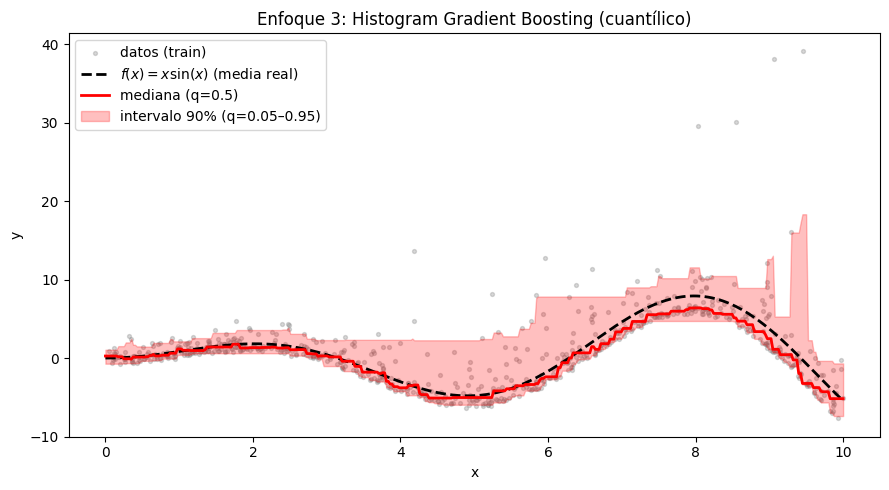

In [79]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_train, y_train, s=8, alpha=0.3, color="gray", label="datos (train)")
ax.plot(xx, f(xx), "k--", lw=2, label=r"$f(x)=x\sin(x)$ (media real)")
ax.plot(xx, med_h, "r-", lw=2, label="mediana (q=0.5)")
ax.fill_between(xx.ravel(), lo_h, hi_h, alpha=0.25, color="red",
                label="intervalo 90% (q=0.05–0.95)")
ax.set_title("Enfoque 3: Histogram Gradient Boosting (cuantílico)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

## 7. Comparación de los tres enfoques

Visualizamos los tres intervalos del $90\%$ lado a lado sobre la malla, junto a
la media real $f(x)$.

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
configs = [
    ("MLP — NLL Gaussiana",  mu_g,  lo_g,  hi_g,  "blue"),
    ("MLP — NLL t-student",  mu_ts, lo_ts, hi_ts, "purple"),
    ("MLP — Pinball",        med_p, lo_p,  hi_p,  "green"),
    ("HistGradientBoosting", med_h, lo_h,  hi_h,  "red"),
]
for ax, (title, center, lo, hi, c) in zip(axes, configs):
    ax.scatter(X_train, y_train, s=6, alpha=0.25, color="gray")
    ax.plot(xx, f(xx), "k--", lw=1.5)
    ax.plot(xx, center, color=c, lw=2)
    ax.fill_between(xx.ravel(), lo, hi, alpha=0.25, color=c)
    ax.set_title(title); ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.tight_layout(); plt.show()

### 7.1 Métricas cuantitativas en el conjunto de prueba

Evaluamos cada enfoque con tres métricas, calculadas sobre los datos de
**prueba** (no vistos durante el entrenamiento):

- **Cobertura (*coverage*)**: fracción de observaciones que caen dentro del
  intervalo $90\%$. Idealmente $\approx 0.90$.
- **Ancho medio**: amplitud promedio del intervalo. A igual cobertura, *más
  estrecho es mejor* (intervalos más informativos).
- **Pérdida pinball media**: promedio de la pérdida pinball sobre los tres
  cuantiles. Es la métrica *propia* para evaluar cuantiles (menor es mejor).

In [ ]:
def coverage(y_true, lo, hi):
    return float(np.mean((y_true >= lo) & (y_true <= hi)))

def mean_width(lo, hi):
    return float(np.mean(hi - lo))

def pinball(y_true, y_pred, q):
    err = y_true - y_pred
    return float(np.mean(np.maximum(q * err, (q - 1.0) * err)))

# --- Predicciones de cada enfoque sobre el conjunto de PRUEBA ---
# 1) Gaussiano: cuantiles a partir de (mu, sigma)
mu_t, sigma_t = gaussian_predict(params_nll, Xte)
g_lo, g_med, g_hi = mu_t - Z90 * sigma_t, mu_t, mu_t + Z90 * sigma_t

# 1b) t-student: cuantiles a partir de (mu, sigma, nu) con la t por punto
mu_tt, sigma_tt, nu_tt = tstudent_predict(params_tstudent, Xte)
t90_tt = student_t.ppf(0.95, df=nu_tt)
t_lo, t_med, t_hi = mu_tt - t90_tt * sigma_tt, mu_tt, mu_tt + t90_tt * sigma_tt

# 2) Pinball MLP
q_t = quantile_predict(params_pin, Xte)
p_lo, p_med, p_hi = q_t[:, 0], q_t[:, 1], q_t[:, 2]

# 3) HistGradientBoosting
h_lo = hgb[0.05].predict(X_test)
h_med = hgb[0.50].predict(X_test)
h_hi = hgb[0.95].predict(X_test)

yt = y_test.ravel()
methods = {
    "MLP NLL Gaussiana":   (g_lo, g_med, g_hi),
    "MLP NLL t-student":   (t_lo, t_med, t_hi),
    "MLP Pinball":         (p_lo, p_med, p_hi),
    "HistGradientBoosting":(h_lo, h_med, h_hi),
}

In [82]:
header = f"{'Método':<22}{'Cobertura':>11}{'Ancho medio':>13}{'Pinball':>10}"
print(header)
print("-" * len(header))
for name, (lo, med, hi) in methods.items():
    cov = coverage(yt, lo, hi)
    wid = mean_width(lo, hi)
    pb = np.mean([pinball(yt, lo, 0.05),
                  pinball(yt, med, 0.50),
                  pinball(yt, hi, 0.95)])
    print(f"{name:<22}{cov:>11.3f}{wid:>13.3f}{pb:>10.4f}")
print("\n(Cobertura objetivo del intervalo 90% = 0.900)")

Método                  Cobertura  Ancho medio   Pinball
--------------------------------------------------------
MLP NLL Gaussiana           0.953        7.739    0.4117
MLP Pinball                 0.907        5.686    0.3316
HistGradientBoosting        0.840        5.878    0.3595

(Cobertura objetivo del intervalo 90% = 0.900)


### 7.2 Curvas de pérdida de entrenamiento

Para comparar la convergencia de los dos modelos basados en JAX.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(hist_nll, color="blue"); axes[0].set_title("MLP NLL Gaussiana")
axes[0].set_xlabel("época"); axes[0].set_ylabel("NLL")
axes[1].plot(hist_tstudent, color="purple"); axes[1].set_title("MLP NLL t-student")
axes[1].set_xlabel("época"); axes[1].set_ylabel("NLL")
axes[2].plot(hist_pin, color="green"); axes[2].set_title("MLP Pinball")
axes[2].set_xlabel("época"); axes[2].set_ylabel("pérdida pinball")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Conclusiones

- **MLP + NLL Gaussiana**: estima media y varianza de forma conjunta y entrega
  incertidumbre *paramétrica*. Es elegante y produce $\sigma(x)$ explícita, pero
  asume **simetría** del ruido; como aquí el ruido es asimétrico (log-normal),
  su intervalo no se ajusta perfectamente a las colas.
- **MLP + NLL t-student**: añade los grados de libertad $\nu(x)$, dando **colas
  más pesadas** que la Gaussiana; su NLL es *robusta* a *outliers* porque las
  desviaciones extremas pesan solo de forma **logarítmica** (no cuadrática), de
  modo que el ajuste no se deja arrastrar por ellas. Pero sigue siendo
  **simétrica**: como los *outliers* aquí son de un solo lado (cola derecha del
  ruido log-normal), no puede *capturarlos* sin ensanchar de más el lado
  opuesto. Robustez (ignorar *outliers*) no es lo mismo que cobertura asimétrica.
- **MLP + pinball**: no asume ninguna distribución y captura la **asimetría**
  del ruido directamente con los cuantiles. Riesgo a vigilar: el *cruce de
  cuantiles* (que $q_{0.05} > q_{0.95}$ en alguna región); con datos suficientes
  y una red suave normalmente no ocurre.
- **HistGradientBoosting**: referencia robusta y sin necesidad de
  estandarización; muy competitivo en cobertura y pérdida pinball.

**Idea clave:** una red neuronal puede ir más allá de predecir un único valor —
con la función de pérdida adecuada (**NLL** o **pinball**) modela toda la
**distribución condicional** y, con ello, intervalos de predicción.

> **Ejercicios propuestos**
> 1. Entrena el MLP pinball con **redes separadas** por cuantil y compara.
> 2. Cambia las capas ocultas (`[1, 32, 2]`, `[1, 128, 128, 2]`) y observa el
>    efecto en la suavidad de $\sigma(x)$.
> 3. Añade un cuantil $0.5$ al modelo Gaussiano (la media) y compáralo con la
>    mediana pinball.
> 4. Implementa *mini-batches* en la función `train` en vez de *full-batch*.